Importando a base de dados:

In [1]:
import os

print(os.listdir('.'))

['.git', '.gitignore', 'Classification.ipynb', 'LICENSE', 'README.md', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [2]:
import pandas as pd

dados = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

dados

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Análise Exploratória dos Dados

In [3]:
dados.shape

(7043, 21)

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
dados[dados.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [7]:
dados.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
dados.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Não há dados duplicados, "null" ou "nan" presente na base de dados.

In [9]:
colunas = dados.columns

for i, coluna in enumerate(colunas):
    print(f'{i+1}. {coluna}: {dados[coluna].unique()}, ({len(dados[coluna].unique())})')


1. customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'], (7043)
2. gender: ['Female' 'Male'], (2)
3. SeniorCitizen: [0 1], (2)
4. Partner: ['Yes' 'No'], (2)
5. Dependents: ['No' 'Yes'], (2)
6. tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], (73)
7. PhoneService: ['No' 'Yes'], (2)
8. MultipleLines: ['No phone service' 'No' 'Yes'], (3)
9. InternetService: ['DSL' 'Fiber optic' 'No'], (3)
10. OnlineSecurity: ['No' 'Yes' 'No internet service'], (3)
11. OnlineBackup: ['Yes' 'No' 'No internet service'], (3)
12. DeviceProtection: ['No' 'Yes' 'No internet service'], (3)
13. TechSupport: ['No' 'Yes' 'No internet service'], (3)
14. StreamingTV: ['No' 'Yes' 'No internet service'], (3)
15. StreamingMovies: ['No' 'Yes' 'No internet service'], (3)
16. Contract: ['Month-to-mon

In [10]:
dados['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
dados['TotalCharges'] = pd.to_numeric(dados['TotalCharges'], errors = 'coerce')

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
dados[dados['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
indices_nan = dados[dados['TotalCharges'].isna()].index
indices_nan

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

Observa-se como padrão na base de dados, que os clientes começam a pagar depois do primeiro mês de serviço. Sendo assim, serão substituídos esses valores "NaN" da coluna "TotalCharges" por "0".

In [8]:
dados['TotalCharges'] = dados['TotalCharges'].fillna(0)

dados.loc[indices_nan]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [ ]:
dados[dados['TotalCharges'] == ' ']

In [17]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<function matplotlib.pyplot.show(close=None, block=None)>

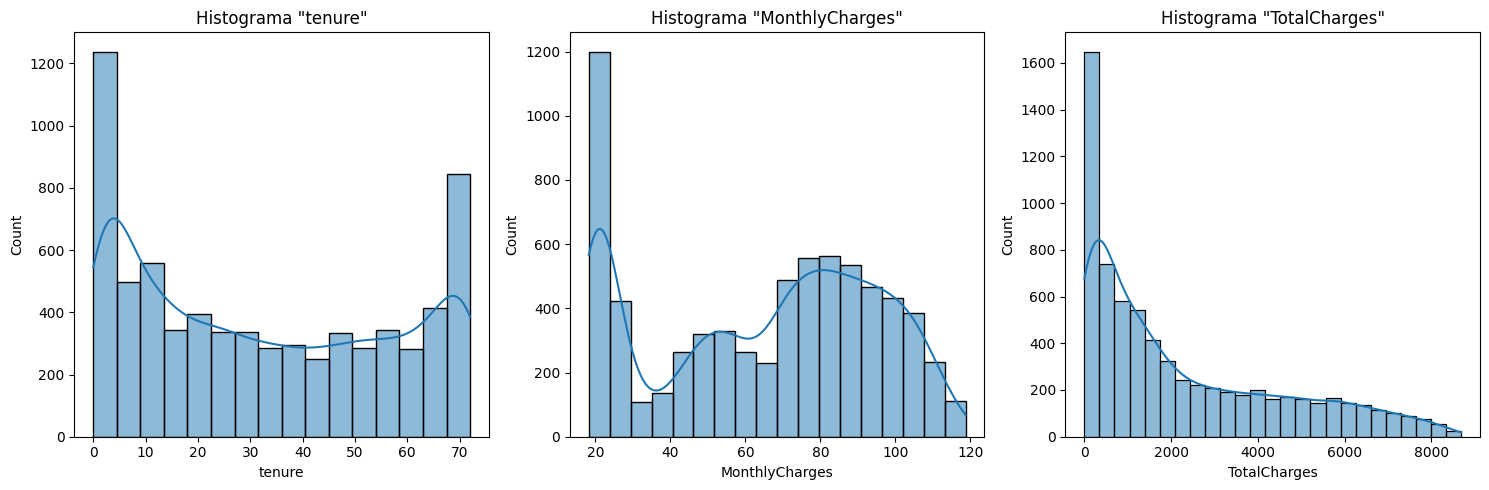

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

coluna_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 5))

for i, coluna in enumerate(coluna_num):
    axes[i].set_title(f'Histograma \"{coluna}\"')
    sns.histplot(dados[coluna], kde = True, ax = axes[i])

plt.tight_layout()
plt.show


In [23]:
import phik

#Preparando dados
ddos = dados.copy()

ddos = ddos.drop('customerID', axis = 1)
ddos['TotalCharges'] = pd.to_numeric(ddos['TotalCharges'], errors = 'coerce')
ddos['TotalCharges'] = ddos['TotalCharges'].fillna(0)

matriz_corr = ddos.phik_matrix()

matriz_corr

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009025,0.000000,0.000000
SeniorCitizen,0.000000,1.000000,0.016992,0.324576,0.028663,0.000000,0.087925,0.160702,0.127319,0.109995,0.110177,0.135283,0.111714,0.113778,0.086231,0.242133,0.292725,0.304691,0.149384,0.233432
Partner,0.000000,0.016992,1.000000,0.652122,0.491658,0.019540,0.086249,0.000000,0.091202,0.092012,0.100092,0.076326,0.082251,0.077506,0.179736,0.013218,0.243008,0.203237,0.424467,0.232930
Dependents,0.000000,0.324576,0.652122,1.000000,0.212209,0.000000,0.011198,0.108463,0.117219,0.097766,0.094597,0.109753,0.088193,0.084684,0.147680,0.172593,0.224903,0.184213,0.119077,0.253936
tenure,0.000000,0.028663,0.491658,0.212209,1.000000,0.000000,0.374604,0.019357,0.365936,0.401085,0.401463,0.363817,0.321011,0.331299,0.664660,0.000000,0.375115,0.411002,0.842146,0.474001
PhoneService,0.000000,0.000000,0.019540,0.000000,0.000000,1.000000,1.000000,0.278954,0.106021,0.103910,0.103604,0.106451,0.108565,0.106784,0.000000,0.016811,0.000000,0.831362,0.198660,0.000000
MultipleLines,0.000000,0.087925,0.086249,0.011198,0.374604,1.000000,1.000000,0.739808,0.540261,0.562933,0.564610,0.541088,0.586049,0.586815,0.244410,0.099953,0.174849,0.710101,0.493936,0.021922
InternetService,0.000000,0.160702,0.000000,0.108463,0.019357,0.278954,0.739808,1.000000,0.949498,0.942842,0.942811,0.948914,0.946713,0.946294,0.505187,0.231438,0.323886,0.918980,0.508222,0.196202
OnlineSecurity,0.001460,0.127319,0.091202,0.117219,0.365936,0.106021,0.540261,0.949498,1.000000,0.947224,0.946787,0.952651,0.943082,0.943248,0.636884,0.208320,0.315799,0.812633,0.529684,0.211840
OnlineBackup,0.000000,0.109995,0.092012,0.097766,0.401085,0.103910,0.562933,0.942842,0.947224,1.000000,0.947487,0.947756,0.945789,0.945395,0.581660,0.195321,0.293413,0.818858,0.567762,0.177422


Pesquisar melhor como funciona a biblioteca de correlação philk, aproveitar e aplicar alguns métodos específicos de correlação à mão (Cramer's V, Pearson) para verificar se a biblioteca philk tem resultados consistentes.